In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv ("C:/Users/mayan/OneDrive/Desktop/Mayank(HP)/programs/Learning_AIML/Cleaned_data/thyroid_dataset.csv")

In [3]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [4]:
X = df.drop("Outlier_label",axis = 1)
y = df["Outlier_label"]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42
)

In [7]:
labels = clf.fit_predict(X_scaled)

In [8]:
# Visualize 
from sklearn.decomposition import PCA

pca = PCA( n_components = 2)

X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'PCA2')

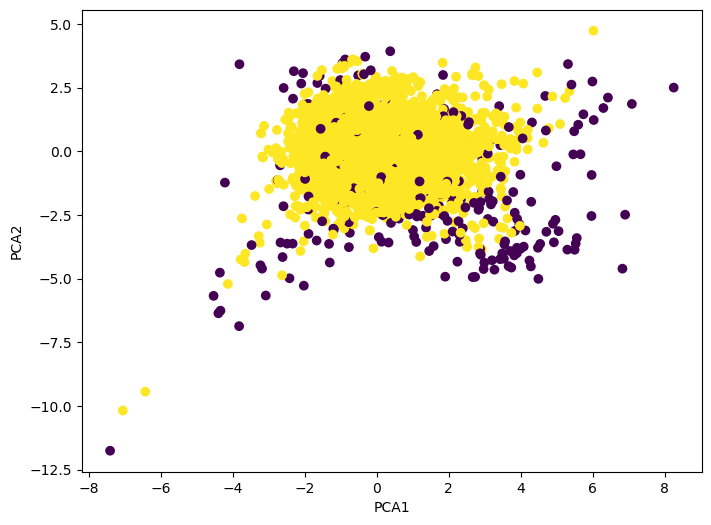

In [9]:
plt.figure(figsize= (8,6))

plt.scatter(X_pca[:,0] , X_pca[:,1] , c = labels)

plt.xlabel("PCA1")
plt.ylabel("PCA2")

In [10]:
import numpy as np 
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print ("Number of Thyroid positive patients =" ,n_outliers)
print("Number of normal patients =" , n_normal)

Number of Thyroid positive patients = 275
Number of normal patients = 6641


# LOF

In [12]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [17]:
# LOF = Local Outlier Factor 

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor( contamination = 0.036)

Lof_labels = lof.fit_predict(X_scaled)

Text(0, 0.5, 'PCA2')

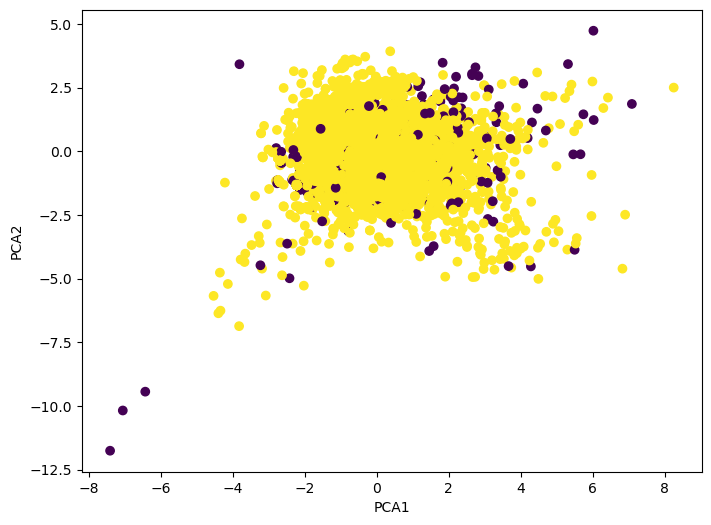

In [18]:
plt.figure(figsize= (8,6))

plt.scatter(X_pca[:,0] , X_pca[:,1] , c = Lof_labels)

plt.xlabel("PCA1")
plt.ylabel("PCA2")

In [19]:

n_outliers = np.sum(Lof_labels == -1)
n_normal = np.sum(Lof_labels == 1)

print ("Number of Thyroid positive patients =" ,n_outliers)
print("Number of normal patients =" , n_normal)

Number of Thyroid positive patients = 249
Number of normal patients = 6667
